In [89]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
import zipfile

In [90]:
with zipfile.ZipFile("emotion_data.zip","r") as zip_data:
    zip_data.extractall("emotion_data")

In [91]:
data_path = "emotion_data/6 Emotions for image classification"
classes = ["anger","fear","happy","sad"]

In [92]:
x = []
y = []

for i in range(len(classes)):
    folder_name = classes[i]
    folder_path = data_path + "/" + folder_name
    print(folder_path)

    images = os.listdir(folder_path)
    for im in images:
        img_path = folder_path + "/" + im
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.resize(img,(150,150))
        img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

        x.append(img)
        y.append(folder_name)

x = np.array(x)
y = np.array(y)

x.shape , y.shape

emotion_data/6 Emotions for image classification/anger
emotion_data/6 Emotions for image classification/fear
emotion_data/6 Emotions for image classification/happy
emotion_data/6 Emotions for image classification/sad


((718, 150, 150), (718,))

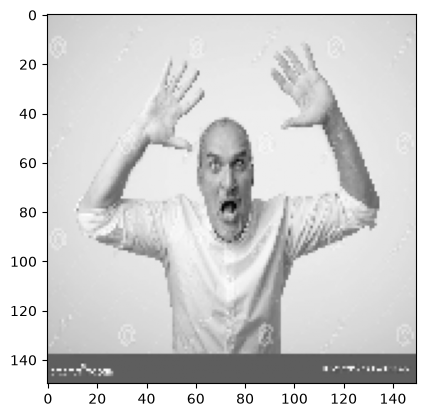

In [93]:
plt.imshow(x[0],cmap="gray")
plt.show()

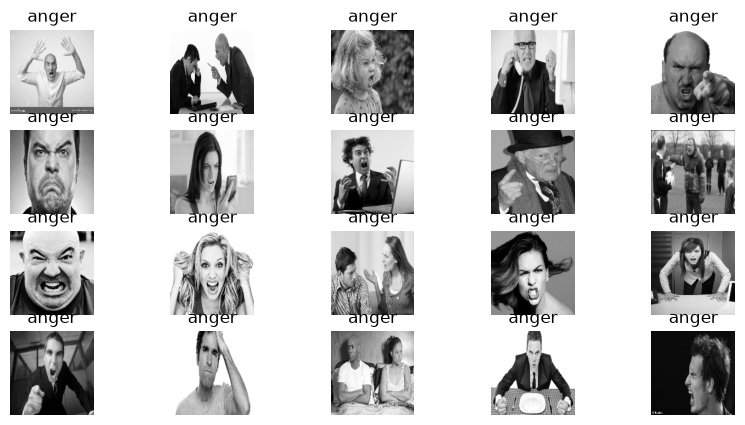

In [94]:
plt.figure(figsize=(10,5))
for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(x[i],cmap="gray")
    plt.title(y[i])
    plt.axis("off")
plt.show()

In [95]:
x[0]

array([[195, 197, 198, ..., 206, 206, 206],
       [197, 197, 200, ..., 208, 206, 206],
       [197, 199, 200, ..., 208, 206, 206],
       ...,
       [ 94,  94,  94, ...,  94,  94,  94],
       [ 94,  94,  94, ...,  94,  94,  94],
       [ 94,  94,  94, ...,  94,  94,  94]], shape=(150, 150), dtype=uint8)

In [96]:
x = x.astype("float")/255
x[0]

array([[0.76470588, 0.77254902, 0.77647059, ..., 0.80784314, 0.80784314,
        0.80784314],
       [0.77254902, 0.77254902, 0.78431373, ..., 0.81568627, 0.80784314,
        0.80784314],
       [0.77254902, 0.78039216, 0.78431373, ..., 0.81568627, 0.80784314,
        0.80784314],
       ...,
       [0.36862745, 0.36862745, 0.36862745, ..., 0.36862745, 0.36862745,
        0.36862745],
       [0.36862745, 0.36862745, 0.36862745, ..., 0.36862745, 0.36862745,
        0.36862745],
       [0.36862745, 0.36862745, 0.36862745, ..., 0.36862745, 0.36862745,
        0.36862745]], shape=(150, 150))

In [97]:
encoder = preprocessing.LabelEncoder()
y = encoder.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [98]:
one_hot_y_1 = pd.get_dummies(y,prefix="emotion")
one_hot_y_1

,emotion_0,emotion_1,emotion_2,emotion_3
0,True,False,False,False
1,True,False,False,False
2,True,False,False,False
3,True,False,False,False
4,True,False,False,False
...,...,...,...,...
713,False,False,False,True
714,False,False,False,True
715,False,False,False,True
716,False,False,False,True


In [99]:
x_train , x_test , y_train , y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((574, 150, 150), (144, 150, 150), (574,), (144,))

In [100]:
x_train[0].shape

(150, 150)

In [101]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation="relu",input_shape=(150, 150, 1)))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(4,activation="softmax"))
model.summary()

c:\Users\pouya\AppData\Local\Programs\Python\Python314\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 175232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │       700,932 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 701,252 (2.68 MB)

 Trainable params: 701,252 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

In [102]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [103]:
hist = model.fit(x_train,y_train,epochs=10,
                 validation_data = (x_test,y_test))

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.2387 - loss: 3.6787 - val_accuracy: 0.2917 - val_loss: 1.8294
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.3606 - loss: 1.5471 - val_accuracy: 0.3472 - val_loss: 1.3883
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.6341 - loss: 1.0217 - val_accuracy: 0.3264 - val_loss: 1.3232
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.7648 - loss: 0.7512 - val_accuracy: 0.3681 - val_loss: 1.3163
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.8659 - loss: 0.5650 - val_accuracy: 0.3194 - val_loss: 1.4165
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.9164 - loss: 0.4167 - val_accuracy: 0.3681 - val_loss: 1.3903
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.9634 - loss: 0.2931 - val_accuracy: 0.3889 - val_loss: 1.4405
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9843 - loss: 0.2020 - val_accuracy: 0.3403 - 

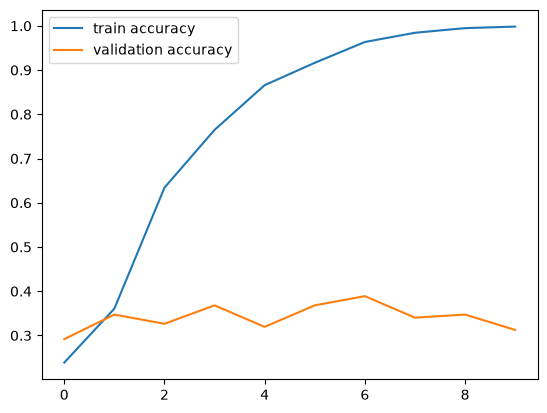

In [104]:
# نمودارهای loss و accuracy را رسم کنید
plt.plot(hist.history["accuracy"],label="train accuracy")
plt.plot(hist.history["val_accuracy"],label="validation accuracy")
plt.legend()
plt.show()

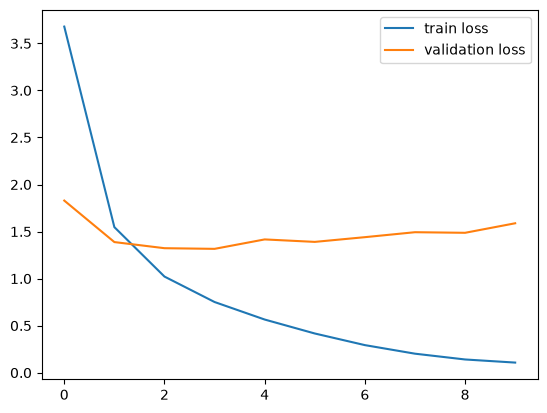

In [105]:
plt.plot(hist.history["loss"],label="train loss")
plt.plot(hist.history["val_loss"],label="validation loss")
plt.legend()
plt.show()

(326, 236, 3)


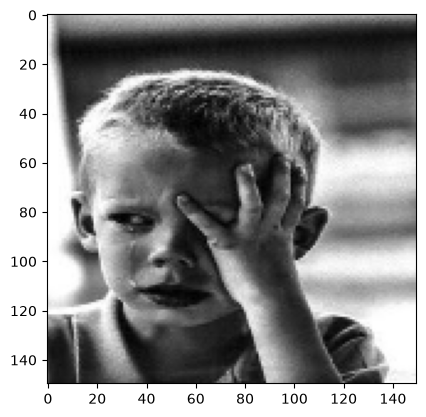

In [106]:
# یک عکس از صورت از اینترنت پیدا کنید و پردازش های لازم را
# انجام دهید و احساسش را پیش بینی کنید

image = cv2.imread("sad.jpeg")
print(image.shape)

image_150 = cv2.resize(image,(150,150))
image_gray = cv2.cvtColor(image_150,cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray,cmap="gray")
plt.show()

In [107]:
print(image_gray.shape)
image_gray = image_gray.reshape(1,150,150,1)
print(image_gray.shape)

(150, 150)
(1, 150, 150, 1)


In [108]:
y_pred = model.predict(image_gray)
y_result = np.argmax(y_pred)
y_class = classes[y_result]
print("it is",y_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
it is fear
